# Watermark Detection: Sobel + CNN


In [ ]:
!pip install opencv-python matplotlib numpy torch torchvision tqdm kagglehub pillow


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from PIL import Image
from tqdm import tqdm
import os

EPS = 1e-6


## 1. WatermarkDetector Class Definition


In [ ]:
class WatermarkDetector:
    def __init__(
        self,
        sobel_ksize=3,
        p_low=8, p_high=80,
        tile_rows=4, tile_cols=6,
        tile_p_low=7, tile_p_high=70,
        border_frac=0.33,
        horiz_deg=23,
        max_boxes=1,
        cnn_model_path=None
    ):
        self.sobel_ksize = sobel_ksize
        self.p_low, self.p_high = p_low, p_high
        self.tile_rows, self.tile_cols = tile_rows, tile_cols
        self.tile_p_low, self.tile_p_high = tile_p_low, tile_p_high
        self.border_frac = border_frac
        self.horiz_deg = horiz_deg
        self.max_boxes = max_boxes

        self.cnn = None
        self.cnn_device = "cuda" if torch.cuda.is_available() else "cpu"
        self.cnn_transform = None
        self.last_max_prob = None

        if cnn_model_path is not None:
            self._load_cnn(cnn_model_path)

    def _load_cnn(self, path):
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 2)
        state = torch.load(path, map_location=self.cnn_device)
        model.load_state_dict(state)
        model.to(self.cnn_device)
        model.eval()

        self.cnn = model
        self.cnn_transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5],
                                 std=[0.5, 0.5, 0.5]),
        ])

    def preprocess_image(self, image):
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
        L = lab[:, :, 0]
        clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
        return clahe.apply(L)

    def apply_sobel(self, image):
        gx = cv2.Sobel(image, cv2.CV_32F, 1, 0, ksize=self.sobel_ksize)
        gy = cv2.Sobel(image, cv2.CV_32F, 0, 1, ksize=self.sobel_ksize)
        mag = cv2.magnitude(gx, gy)
        ang = cv2.phase(gx, gy, angleInDegrees=False)
        return (mag, ang,
                cv2.convertScaleAbs(gx),
                cv2.convertScaleAbs(gy),
                cv2.convertScaleAbs(mag))

    def _band_from_percentiles(self, mag, lo, hi):
        flat = mag.reshape(-1)
        nz = flat[flat > 0]
        if nz.size < 100:
            a, b = 4.0, 50.0
        else:
            a = np.percentile(nz, lo)
            b = np.percentile(nz, hi)
        band = ((mag >= a) & (mag <= b)).astype(np.uint8) * 255
        band = cv2.dilate(band, cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2)), 1)
        return band

    def _tile_adaptive_band(self, mag):
        H, W = mag.shape
        rh, cw = H // self.tile_rows, W // self.tile_cols
        out = np.zeros_like(mag, dtype=np.uint8)
        for r in range(self.tile_rows):
            for c in range(self.tile_cols):
                y0, y1 = r * rh, H if r == self.tile_rows - 1 else (r + 1) * rh
                x0, x1 = c * cw, W if c == self.tile_cols - 1 else (c + 1) * cw
                tile = mag[y0:y1, x0:x1]
                band = self._band_from_percentiles(tile, self.tile_p_low, self.tile_p_high)
                out[y0:y1, x0:x1] = band
        out = cv2.medianBlur(out, 3)
        return out

    def _border_band(self, mag):
        H, W = mag.shape
        t = int(self.border_frac * H)
        l = int(self.border_frac * W)
        band = np.zeros_like(mag, dtype=np.uint8)
        band[:t, :] = self._band_from_percentiles(mag[:t, :], 4, 70)
        band[H - t:, :] = self._band_from_percentiles(mag[H - t:, :], 4, 70)
        band[:, :l] = cv2.max(band[:, :l], self._band_from_percentiles(mag[:, :l], 4, 70))
        band[:, W - l:] = cv2.max(band[:, W - l:], self._band_from_percentiles(mag[:, W - l:], 4, 70))
        band = cv2.morphologyEx(band, cv2.MORPH_CLOSE,
                                cv2.getStructuringElement(cv2.MORPH_RECT, (21, 3)), 2)
        return band

    def _orientation_text_mask(self, mag, ang):
        theta = (ang + np.pi) % (2 * np.pi) - np.pi
        deg = np.abs(theta) * 180.0 / np.pi
        horiz = (deg <= self.horiz_deg) | (deg >= 180 - self.horiz_deg)
        vert  = (deg >= 90 - self.horiz_deg) & (deg <= 90 + self.horiz_deg)

        mag_n = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        _, sig = cv2.threshold(mag_n, 28, 255, cv2.THRESH_BINARY)

        mh = (horiz.astype(np.uint8) * 255) & sig
        mv = (vert.astype(np.uint8) * 255) & sig

        mask = cv2.addWeighted(mh, 1.0, mv, 0.3, 0)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE,
                                cv2.getStructuringElement(cv2.MORPH_RECT, (17, 1)), 2)
        return mask

    def _combine_and_clean(self, band_global, band_tile, band_border, orient):
        weak_all = cv2.bitwise_or(band_global, cv2.bitwise_or(band_tile, band_border))
        combined = cv2.bitwise_and(weak_all, orient)

        H, W = combined.shape
        combined = cv2.morphologyEx(combined, cv2.MORPH_OPEN,
                                    cv2.getStructuringElement(cv2.MORPH_RECT, (1, 5)), 1)
        combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE,
                                    cv2.getStructuringElement(cv2.MORPH_RECT, (23, 3)), 2)
        combined = cv2.morphologyEx(combined, cv2.MORPH_OPEN,
                                    cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)), 1)
        return combined

    def _bottom_band_fallback(self, combined):
        H, W = combined.shape
        band_h = int(0.22 * H)
        y0 = H - band_h
        strip = combined[y0:, :]
        col_density = np.mean(strip == 255, axis=0)
        active = col_density > 0.04
        if not active.any():
            return []
        boxes = []
        start = None
        for x in range(W):
            if active[x] and start is None:
                start = x
            elif not active[x] and start is not None:
                if x - start > 0.15 * W:
                    boxes.append((start, y0, x - start, band_h))
                start = None
        if start is not None and W - start > 0.15 * W:
            boxes.append((start, y0, W - start, band_h))
        return boxes

    def _score_boxes(self, boxes, mask, mag, image):
        if boxes is None or len(boxes) == 0:
            return np.array([], dtype=np.float32)

        if self.cnn is None or self.cnn_transform is None:
            H, W = mask.shape
            mag_n = cv2.normalize(mag, None, 0, 1, cv2.NORM_MINMAX)
            scores = []
            for (x, y, bw, bh) in boxes:
                roi_m = mask[y:y+bh, x:x+bw]
                roi_g = mag_n[y:y+bh, x:x+bw]
                if roi_m.size == 0:
                    scores.append(0.0)
                    continue
                fill = np.mean(roi_m == 255)
                strength = np.mean(roi_g[roi_m == 255]) if np.any(roi_m == 255) else 0.0
                proj = np.sum(roi_m == 255, axis=1) / (bw + EPS)
                bandiness = np.mean((proj > 0.10).astype(np.float32))
                border = min(x, y, W - (x + bw), H - (y + bh))
                border_prior = np.clip(
                    1.0 - (border / max(1, min(H, W) * 0.40)), 0.0, 1.0
                ) * 0.40
                scores.append(
                    float(0.45 * fill + 0.20 * strength + 0.35 * bandiness + border_prior)
                )
            return np.array(scores, dtype=np.float32)

        scores = []
        H, W, _ = image.shape
        for box in boxes:
            x, y, bw, bh = map(int, box)
            x = max(0, x)
            y = max(0, y)
            bw = max(1, min(bw, W - x))
            bh = max(1, min(bh, H - y))
            patch = image[y:y+bh, x:x+bw]
            if patch.size == 0 or bh < 10 or bw < 30:
                scores.append(0.0)
                continue
            patch_rgb = cv2.cvtColor(patch, cv2.COLOR_BGR2RGB)
            pil = Image.fromarray(patch_rgb)
            t = self.cnn_transform(pil).unsqueeze(0).to(self.cnn_device)
            with torch.no_grad():
                logits = self.cnn(t)
                probs = torch.softmax(logits, dim=1)[0, 1].item()
            scores.append(float(probs))
        return np.array(scores, dtype=np.float32)

    def _extract_text_lines(self, mask, gray, mag, image):
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        H, W = gray.shape
        cand = []
        for c in contours:
            x, y, bw, bh = cv2.boundingRect(c)
            area = bw * bh
            if area < 600 or area > H * W * 0.90:
                continue
            ar = bw / float(bh)
            if ar < 1.1 and not (bh >= 12 and 0.6 <= ar <= 2.5):
                continue
            if bh < 6 or bh > int(0.50 * H):
                continue
            sol = cv2.contourArea(c) / (area + EPS)
            if sol < 0.20:
                continue
            if np.mean(mask[y:y+bh, x:x+bw] == 255) < 0.025:
                continue
            pad_x = int(0.02 * W)
            pad_y = int(0.02 * H)
            x = max(0, x - pad_x)
            y = max(0, y - pad_y)
            bw = min(W - x, bw + 2 * pad_x)
            bh = min(H - y, bh + 2 * pad_y)
            cand.append((x, y, bw, bh))

        if not cand:
            return []

        scores = self._score_boxes(cand, mask, mag, image)
        cand_arr = np.array(cand)
        order = np.argsort(-scores)
        cand_arr = cand_arr[order].tolist()
        cand_arr = self._nms(cand_arr, 0.40)
        return cand_arr[:self.max_boxes]

    def _nms(self, boxes, iou_thresh=0.45):
        if not boxes:
            return []
        B = np.array(boxes, dtype=np.float32)
        x1, y1 = B[:, 0], B[:, 1]
        x2, y2 = B[:, 0] + B[:, 2], B[:, 1] + B[:, 3]
        areas = (x2 - x1) * (y2 - y1)
        order = np.argsort(-areas)
        keep = []
        while order.size:
            i = order[0]
            keep.append(i)
            xx1 = np.maximum(x1[i], x1[order[1:]])
            yy1 = np.maximum(y1[i], y1[order[1:]])
            xx2 = np.minimum(x2[i], x2[order[1:]])
            yy2 = np.minimum(y2[i], y2[order[1:]])
            w = np.maximum(0, xx2 - xx1)
            h = np.maximum(0, yy2 - yy1)
            inter = w * h
            iou = inter / (areas[i] + areas[order[1:]] - inter + EPS)
            order = order[1:][iou <= iou_thresh]
        return [tuple(map(int, B[i])) for i in keep]

    def detect_watermark_candidates(self, image):
        gray = self.preprocess_image(image)
        mag, ang, gx_vis, gy_vis, mag_vis = self.apply_sobel(gray)
        band_global = self._band_from_percentiles(mag, self.p_low, self.p_high)
        band_tile   = self._tile_adaptive_band(mag)
        band_border = self._border_band(mag)
        orient      = self._orientation_text_mask(mag, ang)
        combined = self._combine_and_clean(band_global, band_tile, band_border, orient)
        contours, _ = cv2.findContours(combined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        H, W = gray.shape
        cand = []
        for c in contours:
            x, y, bw, bh = cv2.boundingRect(c)
            area = bw * bh
            if area < 600 or area > H * W * 0.90:
                continue
            ar = bw / float(bh)
            if ar < 1.1 and not (bh >= 12 and 0.6 <= ar <= 2.5):
                continue
            if bh < 6 or bh > int(0.50 * H):
                continue
            sol = cv2.contourArea(c) / (area + EPS)
            if sol < 0.20:
                continue
            if np.mean(combined[y:y+bh, x:x+bw] == 255) < 0.025:
                continue
            cand.append((x, y, bw, bh))
        return {
            "gray": gray,
            "magnitude": mag,
            "combined_mask": combined,
            "candidates": cand,
        }

    def detect_watermark_with_sobel(self, image):
        self.last_max_prob = None
        gray = self.preprocess_image(image)
        mag, ang, gx_vis, gy_vis, mag_vis = self.apply_sobel(gray)
        band_global = self._band_from_percentiles(mag, self.p_low, self.p_high)
        band_tile   = self._tile_adaptive_band(mag)
        band_border = self._border_band(mag)
        orient      = self._orientation_text_mask(mag, ang)
        combined = self._combine_and_clean(band_global, band_tile, band_border, orient)
        boxes = self._extract_text_lines(combined, gray, mag, image)
        if not boxes:
            fallback_boxes = self._bottom_band_fallback(combined)
            if fallback_boxes:
                boxes = fallback_boxes
        if self.cnn is not None and boxes:
            probs = self._score_boxes(boxes, combined, mag, image)
            if probs.size > 0:
                self.last_max_prob = float(probs.max())
        return {
            'gray': gray,
            'sobel_x': gx_vis, 'sobel_y': gy_vis, 'magnitude': mag_vis,
            'global_band': band_global,
            'tile_adaptive_mask': band_tile,
            'border_band': band_border,
            'orientation_filter': orient,
            'combined_mask': combined,
            'boxes': boxes
        }

print("WatermarkDetector class defined!")


WatermarkDetector class defined!


## 2. Download Kaggle Dataset


In [ ]:
import kagglehub
import glob
import os

print("Downloading Kaggle dataset...")
try:
    ds_path = kagglehub.dataset_download("felicepollano/watermarked-not-watermarked-images")
    print(f"✓ Dataset downloaded to: {ds_path}")

    DATASET_ROOT = Path(ds_path) / "wm-nowm"
    print(f"Dataset root: {DATASET_ROOT}")

    watermarked_dir = DATASET_ROOT / "train" / "watermark"
    clean_dir = DATASET_ROOT / "train" / "no-watermark"

    print(f"\n=== Path Verification ===")
    print(f"Dataset root: {DATASET_ROOT}")
    print(f"  - Exists: {DATASET_ROOT.exists()}")
    print(f"Watermarked dir: {watermarked_dir}")
    print(f"  - Exists: {watermarked_dir.exists()}")
    print(f"Clean dir: {clean_dir}")
    print(f"  - Exists: {clean_dir.exists()}")

    if watermarked_dir.exists():
        all_wm_images = glob.glob(os.path.join(watermarked_dir.as_posix(), "*.*"))
        print(f"  - Watermarked images: {len(all_wm_images):,}")
        if len(all_wm_images) > 0:
            print(f"    Example: {os.path.basename(all_wm_images[0])}")

    if clean_dir.exists():
        all_no_wm_images = glob.glob(os.path.join(clean_dir.as_posix(), "*.*"))
        print(f"  - Clean images: {len(all_no_wm_images):,}")
        if len(all_no_wm_images) > 0:
            print(f"    Example: {os.path.basename(all_no_wm_images[0])}")

    if not watermarked_dir.exists() or not clean_dir.exists():
        raise ValueError(
            f"Required directories not found.\n"
            f"Watermarked: {watermarked_dir.exists()}\n"
            f"Clean: {clean_dir.exists()}"
        )

except Exception as e:
    print(f"❌ Dataset download failed: {e}")
    print("\nAlternative: Manually upload the dataset or set the path directly.")
    raise


100%|██████████| 698M/698M [00:07<00:00, 103MB/s] 

Extracting files...


✓ Dataset downloaded to: /root/.cache/kagglehub/datasets/felicepollano/watermarked-not-watermarked-images/versions/1
Dataset root: /root/.cache/kagglehub/datasets/felicepollano/watermarked-not-watermarked-images/versions/1/wm-nowm

=== Path Verification ===
Dataset root: /root/.cache/kagglehub/datasets/felicepollano/watermarked-not-watermarked-images/versions/1/wm-nowm
  - Exists: True
Watermarked dir: /root/.cache/kagglehub/datasets/felicepollano/watermarked-not-watermarked-images/versions/1/wm-nowm/train/watermark
  - Exists: True
Clean dir: /root/.cache/kagglehub/datasets/felicepollano/watermarked-not-watermarked-images/versions/1/wm-nowm/train/no-watermark
  - Exists: True
  - Watermarked images: 12,510
    Example: pexels-photo-1784577.jpeg
  - Clean images: 12,477
    Example: pexels-photo-747079.jpeg


## 3. Generate Patch Dataset


In [ ]:
print("=== Image Path Verification ===")
print(f"Watermarked dir exists: {watermarked_dir.exists()}")
print(f"Clean dir exists: {clean_dir.exists()}")

if not watermarked_dir.exists():
    raise ValueError(f"Watermarked image directory not found: {watermarked_dir}")
if not clean_dir.exists():
    raise ValueError(f"Clean image directory not found: {clean_dir}")

out_root = Path("patches")
pos_dir = out_root / "positive"
neg_dir = out_root / "negative"
pos_dir.mkdir(parents=True, exist_ok=True)
neg_dir.mkdir(parents=True, exist_ok=True)



det = WatermarkDetector()

def list_images(root: Path):
    exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff", "*.webp")
    out = []
    for pat in exts:
        out.extend(root.rglob(pat))
    return out

def save_patch(img, box, out_dir: Path, base_name: str, idx: int) -> bool:
    try:
        x, y, w, h = box
        H, W, _ = img.shape
        x = max(0, x); y = max(0, y)
        w = max(1, min(w, W - x))
        h = max(1, min(h, H - y))
        patch = img[y:y+h, x:x+w]
        if patch.size == 0:
            return False
        if h < 10 or w < 30:
            return False
        fname = out_dir / f"{base_name}_{idx}.png"
        cv2.imwrite(str(fname), patch)
        return True
    except Exception as e:
        print(f"Error saving patch: {e}")
        return False

print("\nScanning image lists...")
wm_imgs = list_images(watermarked_dir)
clean_imgs = list_images(clean_dir)
print(f"Found {len(wm_imgs):,} watermarked imgs, {len(clean_imgs):,} clean imgs.")

if len(wm_imgs) == 0:
    raise ValueError(f"Watermarked images not found: {watermarked_dir}")
if len(clean_imgs) == 0:
    raise ValueError(f"Clean images not found: {clean_dir}")

if len(wm_imgs) > 0:
    print(f"\nSample watermarked image: {wm_imgs[0]}")
if len(clean_imgs) > 0:
    print(f"Sample clean image: {clean_imgs[0]}")


=== Image Path Verification ===
Watermarked dir exists: True
Clean dir exists: True

Scanning image lists...
Found 12,510 watermarked imgs, 12,477 clean imgs.

Sample watermarked image: /root/.cache/kagglehub/datasets/felicepollano/watermarked-not-watermarked-images/versions/1/wm-nowm/train/watermark/broken-car-vehicle-vintage.jpg
Sample clean image: /root/.cache/kagglehub/datasets/felicepollano/watermarked-not-watermarked-images/versions/1/wm-nowm/train/no-watermark/nature-grass-leaf-green.jpg


In [ ]:
pos_count = 0
neg_count = 0

print("Extracting positive patches from watermarked images...")
processed = 0
failed = 0

for img_path in tqdm(wm_imgs, desc="Processing watermarked images"):
    try:
        img = cv2.imread(str(img_path))
        if img is None:
            failed += 1
            continue
        processed += 1

        res = det.detect_watermark_candidates(img)
        boxes = res["candidates"]
        base = img_path.stem

        if boxes:
            for i, box in enumerate(boxes[:3]):
                if save_patch(img, box, pos_dir, base, i):
                    pos_count += 1
        else:
            H, W, _ = img.shape
            if H < 40 or W < 80:
                continue
            x = np.random.randint(0, max(1, W - 80))
            y = np.random.randint(0, max(1, H - 40))
            box = (x, y, 80, 40)
            if save_patch(img, box, pos_dir, base, 0):
                pos_count += 1
    except Exception as e:
        failed += 1
        if failed <= 5:
            print(f"Error processing {img_path.name}: {e}")

print(f"\nPositive patches: {pos_count}")
print(f"Processed images: {processed}, Failed: {failed}")


Extracting positive patches from watermarked images...


Processing watermarked images: 100%|██████████| 12510/12510 [06:25<00:00, 32.45it/s]


Positive patches: 21175
Processed images: 12510, Failed: 0


In [ ]:
print("Extracting negative patches from clean images...")
processed_neg = 0
failed_neg = 0

for img_path in tqdm(clean_imgs, desc="Processing clean images"):
    try:
        img = cv2.imread(str(img_path))
        if img is None:
            failed_neg += 1
            continue
        processed_neg += 1

        res = det.detect_watermark_candidates(img)
        boxes = res["candidates"]
        base = img_path.stem

        if boxes:
            for i, box in enumerate(boxes[:3]):
                if save_patch(img, box, neg_dir, base, i):
                    neg_count += 1
        else:
            H, W, _ = img.shape
            if H < 40 or W < 80:
                continue
            x = np.random.randint(0, max(1, W - 80))
            y = np.random.randint(0, max(1, H - 40))
            box = (x, y, 80, 40)
            if save_patch(img, box, neg_dir, base, 0):
                neg_count += 1
    except Exception as e:
        failed_neg += 1
        if failed_neg <= 5:
            print(f"Error processing {img_path.name}: {e}")

print(f"\nNegative patches: {neg_count}")
print(f"Processed images: {processed_neg}, Failed: {failed_neg}")
print(f"\n=== Patch Generation Complete ===")
print(f"Total patches: {pos_count + neg_count}")
print(f"  - Positive: {pos_count}")
print(f"  - Negative: {neg_count}")
print(f"Saved under: {out_root}")

actual_pos = len(list(pos_dir.glob("*.png")))
actual_neg = len(list(neg_dir.glob("*.png")))
print(f"\nActually saved files:")
print(f"  - Positive: {actual_pos}")
print(f"  - Negative: {actual_neg}")

if actual_pos == 0 or actual_neg == 0:
    print("\n⚠️ Warning: Patches were not saved properly!")
    print("Please check directory permissions or disk space.")


Extracting negative patches from clean images...


Processing clean images: 100%|██████████| 12477/12477 [06:21<00:00, 32.68it/s]



Negative patches: 20017
Processed images: 12477, Failed: 0

=== Patch Generation Complete ===
Total patches: 41192
  - Positive: 21175
  - Negative: 20017
Saved under: patches

Actually saved files:
  - Positive: 21174
  - Negative: 20017


In [ ]:
import os

pos_count_check = len(list(pos_dir.glob("*.png")))
neg_count_check = len(list(neg_dir.glob("*.png")))

print(f"\n=== Patch Generation Verification ===")
print(f"Positive patches: {pos_count_check}")
print(f"Negative patches: {neg_count_check}")
print(f"Total patches: {pos_count_check + neg_count_check}")

if pos_count_check == 0 or neg_count_check == 0:
    print("\n⚠️ Warning: Not enough patches were generated!")
    print("Please re-run the patch generation cells or check image paths.")
else:
    print("\n✓ Patch generation complete! You can proceed with CNN training.")



=== Patch Generation Verification ===
Positive patches: 21174
Negative patches: 20017
Total patches: 41191

✓ Patch generation complete! You can proceed with CNN training.


## 4. CNN Model Training


In [ ]:
class PatchDataset(Dataset):
    def __init__(self, pos_dir: Path, neg_dir: Path, transform=None):
        self.pos_paths = list(pos_dir.glob("*.png"))
        self.neg_paths = list(neg_dir.glob("*.png"))
        self.all_paths = self.pos_paths + self.neg_paths
        self.labels = [1] * len(self.pos_paths) + [0] * len(self.neg_paths)
        self.transform = transform

    def __len__(self):
        return len(self.all_paths)

    def __getitem__(self, idx):
        img_path = self.all_paths[idx]
        label = self.labels[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

pos_patches = list(pos_dir.glob("*.png"))
neg_patches = list(neg_dir.glob("*.png"))
print(f"\nPatch file verification:")
print(f"Positive patches: {len(pos_patches)}")
print(f"Negative patches: {len(neg_patches)}")

if len(pos_patches) == 0 or len(neg_patches) == 0:
    raise ValueError(
        f"Patch dataset is empty!\n"
        f"Positive: {len(pos_patches)}, Negative: {len(neg_patches)}\n"
        f"Please re-run the patch generation step."
    )

EPOCHS = 10
BATCH_SIZE = 32
LR = 0.001
OUTPUT_MODEL = "watermark_cnn_best.pth"

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

dataset = PatchDataset(pos_dir, neg_dir, transform=transform)
print(f"\nTotal dataset size: {len(dataset)}")

if len(dataset) == 0:
    raise ValueError("Dataset is empty! Please re-run the patch generation step.")

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


Using device: cuda

Patch file verification:
Positive patches: 21174
Negative patches: 20017

Total dataset size: 41191
Train samples: 32952, Val samples: 8239


In [ ]:
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)

print("Model initialized!")


Model initialized!


In [ ]:
best_val_loss = float("inf")

history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': [],
    'epoch': []
}

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs = imgs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)

    train_loss = running_loss / len(train_dataset)

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * labels.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_dataset)
    val_acc = 100 * correct / total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['epoch'].append(epoch + 1)

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), OUTPUT_MODEL)
        print(f"✓ Saved best model to {OUTPUT_MODEL}")

print(f"\nTraining complete! Best model saved to {OUTPUT_MODEL}")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best validation accuracy: {max(history['val_acc']):.2f}%")


Epoch 1/10: 100%|██████████| 1030/1030 [01:11<00:00, 14.32it/s]


Epoch 1/10 - Train Loss: 0.6993, Val Loss: 0.6956, Val Acc: 54.01%
✓ Saved best model to watermark_cnn_best.pth


Epoch 2/10: 100%|██████████| 1030/1030 [01:11<00:00, 14.45it/s]


Epoch 2/10 - Train Loss: 0.6756, Val Loss: 0.6658, Val Acc: 55.20%
✓ Saved best model to watermark_cnn_best.pth


Epoch 3/10: 100%|██████████| 1030/1030 [01:11<00:00, 14.37it/s]


...

Epoch 8/10 - Train Loss: 0.6497, Val Loss: 0.6508, Val Acc: 56.29%


Epoch 9/10: 100%|██████████| 1030/1030 [01:11<00:00, 14.42it/s]


Epoch 9/10 - Train Loss: 0.6485, Val Loss: 0.6499, Val Acc: 56.50%
✓ Saved best model to watermark_cnn_best.pth


Epoch 10/10: 100%|██████████| 1030/1030 [01:12<00:00, 14.18it/s]


Epoch 10/10 - Train Loss: 0.6466, Val Loss: 0.6460, Val Acc: 57.31%
✓ Saved best model to watermark_cnn_best.pth

Training complete! Best model saved to watermark_cnn_best.pth
Best validation loss: 0.6460
Best validation accuracy: 57.31%


### Training Curve Visualization


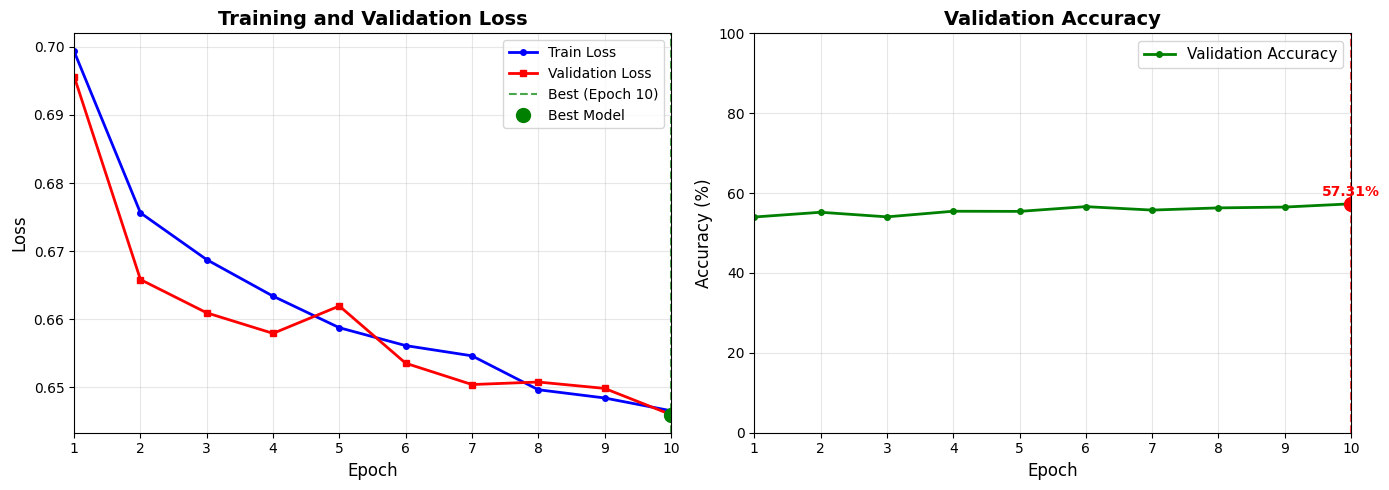


=== Training Summary ===
Metric                    Value          
----------------------------------------
Total Epochs              10
Best Epoch (Loss)         10
Best Val Loss             0.6460
Best Val Accuracy         57.31%
Final Train Loss          0.6466
Final Val Loss            0.6460
Final Val Accuracy        57.31%


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = history['epoch']

ax1 = axes[0]
ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2, marker='o', markersize=4)
ax1.plot(epochs, history['val_loss'], 'r-', label='Validation Loss', linewidth=2, marker='s', markersize=4)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([1, EPOCHS])

best_epoch_idx = np.argmin(history['val_loss'])
best_epoch = epochs[best_epoch_idx]
best_val_loss = history['val_loss'][best_epoch_idx]
ax1.axvline(x=best_epoch, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Best (Epoch {best_epoch})')
ax1.plot(best_epoch, best_val_loss, 'go', markersize=10, label='Best Model')
ax1.legend(fontsize=10)

ax2 = axes[1]
ax2.plot(epochs, history['val_acc'], 'g-', label='Validation Accuracy', linewidth=2, marker='o', markersize=4)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([1, EPOCHS])
ax2.set_ylim([0, 100])

best_acc = max(history['val_acc'])
best_acc_epoch = epochs[np.argmax(history['val_acc'])]
ax2.axvline(x=best_acc_epoch, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.plot(best_acc_epoch, best_acc, 'ro', markersize=10)
ax2.text(best_acc_epoch, best_acc + 2, f'{best_acc:.2f}%',
         ha='center', fontsize=10, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

print("\n=== Training Summary ===")
print(f"{'Metric':<25} {'Value':<15}")
print("-" * 40)
print(f"{'Total Epochs':<25} {EPOCHS}")
print(f"{'Best Epoch (Loss)':<25} {best_epoch}")
print(f"{'Best Val Loss':<25} {best_val_loss:.4f}")
print(f"{'Best Val Accuracy':<25} {best_acc:.2f}%")
print(f"{'Final Train Loss':<25} {history['train_loss'][-1]:.4f}")
print(f"{'Final Val Loss':<25} {history['val_loss'][-1]:.4f}")
print(f"{'Final Val Accuracy':<25} {history['val_acc'][-1]:.2f}%")


## 5. Watermark Detection with Sobel + CNN


In [ ]:
detector = WatermarkDetector(cnn_model_path=OUTPUT_MODEL)
print("Detector initialized with CNN model!")


Detector initialized with CNN model!


In [ ]:
# 시각화 함수
def visualize_results(results, save_path=None):
    fig = plt.figure(figsize=(14, 8))

    ax1 = plt.subplot(3, 4, 1)
    ax1.imshow(cv2.cvtColor(results['original'], cv2.COLOR_BGR2RGB))
    ax1.set_title('1. Original Image', fontsize=9, fontweight='bold')
    ax1.axis('off')

    ax2 = plt.subplot(3, 4, 2)
    ax2.imshow(results['preprocessed'], cmap='gray')
    ax2.set_title('2. Preprocessed (CLAHE)', fontsize=9)
    ax2.axis('off')

    ax3 = plt.subplot(3, 4, 3)
    ax3.imshow(results['sobel_magnitude'], cmap='gray')
    ax3.set_title('3. Sobel Magnitude', fontsize=9)
    ax3.axis('off')

    ax4 = plt.subplot(3, 4, 4)
    ax4.imshow(results['global_band'], cmap='gray')
    ax4.set_title('4. Global Band', fontsize=9)
    ax4.axis('off')

    ax5 = plt.subplot(3, 4, 5)
    ax5.imshow(results['tile_adaptive'], cmap='gray')
    ax5.set_title('5. Tile-Adaptive Band', fontsize=9)
    ax5.axis('off')

    ax6 = plt.subplot(3, 4, 6)
    ax6.imshow(results['border_band'], cmap='gray')
    ax6.set_title('6. Border Band', fontsize=9)
    ax6.axis('off')

    ax7 = plt.subplot(3, 4, 7)
    ax7.imshow(results['orientation_filter'], cmap='gray')
    ax7.set_title('7. Orientation Filter', fontsize=9)
    ax7.axis('off')

    ax8 = plt.subplot(3, 4, 8)
    ax8.imshow(results['combined_mask'], cmap='gray')
    ax8.set_title('8. Combined Mask', fontsize=9, fontweight='bold')
    ax8.axis('off')

    ax9 = plt.subplot(3, 4, 9)
    vis = results['original'].copy()
    for (x, y, w, h) in results['bounding_boxes']:
        cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 3)
        cv2.putText(vis, 'WATERMARK', (x, max(0, y - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    ax9.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax9.set_title(
        '9. Final Result\n' + ('✓ DETECTED' if results['bounding_boxes'] else '✗ NOT DETECTED'),
        fontsize=9,
        fontweight='bold',
        color=('green' if results['bounding_boxes'] else 'red')
    )
    ax9.axis('off')

    ax10 = plt.subplot(3, 4, 10)
    if detector.cnn is not None and detector.last_max_prob is not None:
        prob = detector.last_max_prob
        ax10.barh(['CNN Confidence'], [prob], color='blue', alpha=0.7)
        ax10.set_xlim([0, 1])
        ax10.set_xlabel('Probability', fontsize=8)
        ax10.axvline(0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Threshold')
        ax10.text(prob, 0, f'{prob:.3f}', ha='left' if prob < 0.5 else 'right',
                 va='center', fontsize=10, fontweight='bold',
                 color='red' if prob < 0.5 else 'green')
        ax10.set_title(f'10. CNN Confidence\n{"✓ Positive" if prob > 0.5 else "✗ Negative"}',
                      fontsize=9, fontweight='bold',
                      color=('green' if prob > 0.5 else 'red'))
        ax10.legend(fontsize=7)
    else:
        ax10.text(0.5, 0.5, 'CNN\nNot Used',
                 ha='center', va='center', fontsize=10,
                 transform=ax10.transAxes, color='gray')
        ax10.set_title('10. CNN Confidence', fontsize=9)
    ax10.axis('off')

    plt.tight_layout(pad=1.5)
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


## 6. Evaluation Metrics


In [ ]:
EPS = 1e-6


In [ ]:
print("=== Image-level Classification Metrics ===")
print("Evaluating detector as binary classifier: watermark vs no-watermark\n")

MAX_EVAL_IMAGES = 100

watermarked_images = list(watermarked_dir.glob("*.*"))[:MAX_EVAL_IMAGES] if MAX_EVAL_IMAGES else list(watermarked_dir.glob("*.*"))
no_watermark_images = list(clean_dir.glob("*.*"))[:MAX_EVAL_IMAGES] if MAX_EVAL_IMAGES else list(clean_dir.glob("*.*"))

all_images = []
for img_path in watermarked_images:
    all_images.append((img_path, 1))
for img_path in no_watermark_images:
    all_images.append((img_path, 0))

print(f"Total images to evaluate: {len(all_images):,}")
print(f"  - Watermarked images: {len(watermarked_images):,}")
print(f"  - No-watermark images: {len(no_watermark_images):,}\n")

TP = 0
FP = 0
FN = 0
TN = 0

all_detections = []
all_boxes_info = []

for img_path, true_label in tqdm(all_images, desc="Evaluating"):
    try:
        image = cv2.imread(str(img_path))
        if image is None:
            continue

        results = detector.detect_watermark_with_sobel(image)
        boxes = results['boxes']

        pred_label = 1 if len(boxes) > 0 else 0

        if true_label == 1 and pred_label == 1:
            TP += 1
        elif true_label == 0 and pred_label == 1:
            FP += 1
        elif true_label == 1 and pred_label == 0:
            FN += 1
        elif true_label == 0 and pred_label == 0:
            TN += 1

        H, W = image.shape[:2]
        for box in boxes:
            x, y, w, h = box
            box_area = w * h
            box_ratio = w / h if h > 0 else 0
            center_x, center_y = x + w/2, y + h/2
            img_center_x, img_center_y = W/2, H/2
            distance_from_center = np.sqrt((center_x - img_center_x)**2 + (center_y - img_center_y)**2)
            normalized_distance = distance_from_center / np.sqrt(W**2 + H**2)

            all_boxes_info.append({
                'area': box_area,
                'width': w,
                'height': h,
                'aspect_ratio': box_ratio,
                'area_ratio': box_area / (H * W),
                'distance_from_center': normalized_distance,
                'x': x,
                'y': y
            })

        all_detections.append({
            'image': img_path.name,
            'true_label': true_label,
            'pred_label': pred_label,
            'num_boxes': len(boxes),
            'cnn_prob': detector.last_max_prob if detector.last_max_prob is not None else None,
            'boxes': boxes
        })
    except Exception as e:
        print(f"Error processing {img_path.name}: {e}")
        continue

total = TP + FP + FN + TN
accuracy = (TP + TN) / (total + EPS)
precision = TP / (TP + FP + EPS)
recall = TP / (TP + FN + EPS)
f1 = 2 * (precision * recall) / (precision + recall + EPS)
specificity = TN / (TN + FP + EPS)

print(f"\n=== Confusion Matrix ===")
print(f"                Predicted")
print(f"              Positive  Negative")
print(f"Actual Positive  {TP:4d}     {FN:4d}")
print(f"       Negative  {FP:4d}     {TN:4d}")

print(f"\n=== Classification Metrics ===")
print(f"{'Metric':<30} {'Value':<15} {'Description'}")
print("-" * 70)
print(f"{'Accuracy':<30} {accuracy:.4f} ({accuracy*100:.2f}%)  {'(TP + TN) / Total'}")
print(f"{'Precision':<30} {precision:.4f} ({precision*100:.2f}%)  {'When I say watermark, how often am I right?'}")
print(f"{'Recall (Sensitivity)':<30} {recall:.4f} ({recall*100:.2f}%)  {'How many real watermarks do I catch?'}")
print(f"{'F1-Score':<30} {f1:.4f} ({f1*100:.2f}%)  {'Harmonic mean of precision & recall'}")
print(f"{'Specificity':<30} {specificity:.4f} ({specificity*100:.2f}%)  {'True Negative Rate'}")
print(f"{'False Positive Rate':<30} {FP/(FP+TN+EPS):.4f} ({FP/(FP+TN+EPS)*100:.2f}%)  {'FP / (FP + TN)'}")
print(f"{'False Negative Rate':<30} {FN/(TP+FN+EPS):.4f} ({FN/(TP+FN+EPS)*100:.2f}%)  {'FN / (TP + FN)'}")

if detector.cnn is not None:
    cnn_probs = [d['cnn_prob'] for d in all_detections if d['cnn_prob'] is not None]
    if len(cnn_probs) > 0:
        print(f"\n=== CNN Confidence Metrics ===")
        print(f"{'Metric':<30} {'Value':<15}")
        print("-" * 45)
        print(f"{'Mean Confidence':<30} {np.mean(cnn_probs):.4f}")
        print(f"{'Std Confidence':<30} {np.std(cnn_probs):.4f}")
        print(f"{'Min Confidence':<30} {np.min(cnn_probs):.4f}")
        print(f"{'Max Confidence':<30} {np.max(cnn_probs):.4f}")
        print(f"{'Confidence > 0.5':<30} {sum(1 for p in cnn_probs if p > 0.5):,} ({sum(1 for p in cnn_probs if p > 0.5)/len(cnn_probs)*100:.2f}%)")
        print(f"{'Confidence > 0.7':<30} {sum(1 for p in cnn_probs if p > 0.7):,} ({sum(1 for p in cnn_probs if p > 0.7)/len(cnn_probs)*100:.2f}%)")

box_counts = [d['num_boxes'] for d in all_detections]
print(f"\n=== Detection Statistics ===")
print(f"{'Metric':<30} {'Value':<15}")
print("-" * 45)
print(f"{'Mean boxes per image':<30} {np.mean(box_counts):.4f}")
print(f"{'Max boxes per image':<30} {np.max(box_counts)}")
print(f"{'Images with boxes':<30} {sum(1 for c in box_counts if c > 0):,} ({sum(1 for c in box_counts if c > 0)/len(all_detections)*100:.2f}%)")

if len(all_boxes_info) > 0:
    print(f"\n=== Localization Quality (Predicted Box Characteristics) ===")
    print(f"{'Metric':<30} {'Mean':<15} {'Std':<15}")
    print("-" * 60)

    areas = [b['area'] for b in all_boxes_info]
    area_ratios = [b['area_ratio'] for b in all_boxes_info]
    aspect_ratios = [b['aspect_ratio'] for b in all_boxes_info]
    distances = [b['distance_from_center'] for b in all_boxes_info]

    print(f"{'Box Area (pixels)':<30} {np.mean(areas):<15.2f} {np.std(areas):<15.2f}")
    print(f"{'Box Area Ratio':<30} {np.mean(area_ratios):<15.4f} {np.std(area_ratios):<15.4f}")
    print(f"{'Aspect Ratio (W/H)':<30} {np.mean(aspect_ratios):<15.4f} {np.std(aspect_ratios):<15.4f}")
    print(f"{'Distance from Center':<30} {np.mean(distances):<15.4f} {np.std(distances):<15.4f}")

    border_threshold = 0.1
    border_boxes = sum(1 for b in all_boxes_info if b['distance_from_center'] > (1 - border_threshold))
    print(f"{'Boxes near border (>90%)':<30} {border_boxes:,} ({border_boxes/len(all_boxes_info)*100:.2f}%)")


=== Image-level Classification Metrics ===
Evaluating detector as binary classifier: watermark vs no-watermark

Total images to evaluate: 200
  - Watermarked images: 100
  - No-watermark images: 100



Evaluating: 100%|██████████| 200/200 [00:09<00:00, 20.68it/s]


=== Confusion Matrix ===
                Predicted
              Positive  Negative
Actual Positive    96        4
       Negative    96        4

=== Classification Metrics ===
Metric                         Value           Description
----------------------------------------------------------------------
Accuracy                       0.5000 (50.00%)  (TP + TN) / Total
Precision                      0.5000 (50.00%)  When I say watermark, how often am I right?
Recall (Sensitivity)           0.9600 (96.00%)  How many real watermarks do I catch?
F1-Score                       0.6575 (65.75%)  Harmonic mean of precision & recall
Specificity                    0.0400 (4.00%)  True Negative Rate
False Positive Rate            0.9600 (96.00%)  FP / (FP + TN)
False Negative Rate            0.0400 (4.00%)  FN / (TP + FN)

=== CNN Confidence Metrics ===
Metric                         Value          
---------------------------------------------
Mean Confidence                0.5647
Std Confid

In [ ]:
print("This cell is now integrated into cell 24.")
print("All metrics are calculated in cell 24 using the image-level classification approach.")


This cell is now integrated into cell 24.
All metrics are calculated in cell 24 using the image-level classification approach.


### Evaluation Results Visualization (Prediction-based)


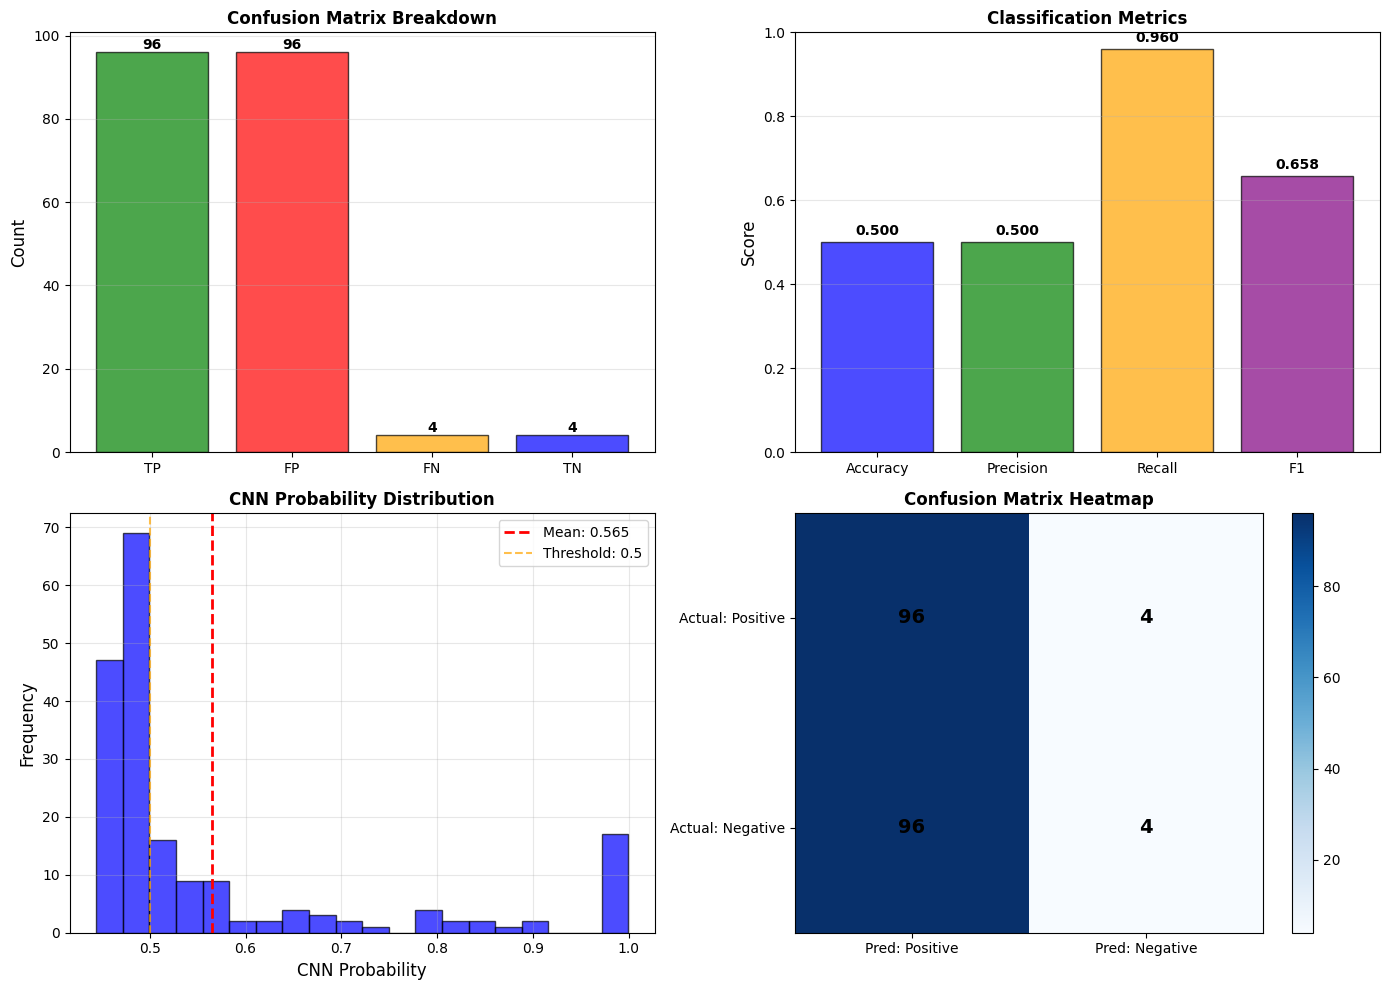


=== Evaluation Summary ===
Metric                         Value          
---------------------------------------------
Total Images                   200
True Positives (TP)            96
False Positives (FP)           96
False Negatives (FN)           4
True Negatives (TN)            4

Accuracy                       0.5000 (50.00%)
Precision                      0.5000 (50.00%)
Recall                         0.9600 (96.00%)
F1-Score                       0.6575 (65.75%)
Specificity                    0.0400 (4.00%)


In [ ]:
import matplotlib.pyplot as plt

try:
    if 'TP' in locals() and 'FP' in locals() and 'FN' in locals() and 'TN' in locals():
        has_metrics = True
    else:
        has_metrics = False
except:
    has_metrics = False

if has_metrics:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax1 = axes[0, 0]
    categories = ['TP', 'FP', 'FN', 'TN']
    counts = [TP, FP, FN, TN]
    colors = ['green', 'red', 'orange', 'blue']
    bars = ax1.bar(categories, counts, color=colors, alpha=0.7, edgecolor='black')
    ax1.set_ylabel('Count', fontsize=12)
    ax1.set_title('Confusion Matrix Breakdown', fontsize=12, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)

    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                 f'{count:,}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax2 = axes[0, 1]
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1']
    metrics_values = [accuracy, precision, recall, f1]
    colors_metrics = ['blue', 'green', 'orange', 'purple']
    bars_metrics = ax2.bar(metrics_names, metrics_values, color=colors_metrics, alpha=0.7, edgecolor='black')
    ax2.set_ylabel('Score', fontsize=12)
    ax2.set_title('Classification Metrics', fontsize=12, fontweight='bold')
    ax2.set_ylim([0, 1])
    ax2.grid(axis='y', alpha=0.3)

    for bar, val in zip(bars_metrics, metrics_values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{val:.3f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax3 = axes[1, 0]
    if detector.cnn is not None:
        cnn_probs = [d['cnn_prob'] for d in all_detections if d['cnn_prob'] is not None]
        if len(cnn_probs) > 0:
            ax3.hist(cnn_probs, bins=20, color='blue', alpha=0.7, edgecolor='black')
            ax3.axvline(np.mean(cnn_probs), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(cnn_probs):.3f}')
            ax3.axvline(0.5, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='Threshold: 0.5')
            ax3.set_xlabel('CNN Probability', fontsize=12)
            ax3.set_ylabel('Frequency', fontsize=12)
            ax3.set_title('CNN Probability Distribution', fontsize=12, fontweight='bold')
            ax3.legend()
            ax3.grid(alpha=0.3)
        else:
            ax3.text(0.5, 0.5, 'No CNN probabilities',
                     ha='center', va='center', fontsize=12, transform=ax3.transAxes)
            ax3.set_title('CNN Probability Distribution', fontsize=12, fontweight='bold')
    else:
        ax3.text(0.5, 0.5, 'CNN not used',
                 ha='center', va='center', fontsize=12, transform=ax3.transAxes)
        ax3.set_title('CNN Probability Distribution', fontsize=12, fontweight='bold')

    ax4 = axes[1, 1]
    confusion_data = np.array([[TP, FN], [FP, TN]])
    im = ax4.imshow(confusion_data, cmap='Blues', aspect='auto')
    ax4.set_xticks([0, 1])
    ax4.set_yticks([0, 1])
    ax4.set_xticklabels(['Pred: Positive', 'Pred: Negative'])
    ax4.set_yticklabels(['Actual: Positive', 'Actual: Negative'])
    ax4.set_title('Confusion Matrix Heatmap', fontsize=12, fontweight='bold')

    for i in range(2):
        for j in range(2):
            text = ax4.text(j, i, confusion_data[i, j],
                           ha="center", va="center", color="black", fontweight='bold', fontsize=14)

    plt.colorbar(im, ax=ax4)
    plt.tight_layout()
    plt.show()

    print("\n=== Evaluation Summary ===")
    print(f"{'Metric':<30} {'Value':<15}")
    print("-" * 45)
    print(f"{'Total Images':<30} {total:,}")
    print(f"{'True Positives (TP)':<30} {TP:,}")
    print(f"{'False Positives (FP)':<30} {FP:,}")
    print(f"{'False Negatives (FN)':<30} {FN:,}")
    print(f"{'True Negatives (TN)':<30} {TN:,}")
    print(f"\n{'Accuracy':<30} {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"{'Precision':<30} {precision:.4f} ({precision*100:.2f}%)")
    print(f"{'Recall':<30} {recall:.4f} ({recall*100:.2f}%)")
    print(f"{'F1-Score':<30} {f1:.4f} ({f1*100:.2f}%)")
    print(f"{'Specificity':<30} {specificity:.4f} ({specificity*100:.2f}%)")
else:
    print("Please run cell 24 first to calculate metrics.")


### 평가 결과 시각화


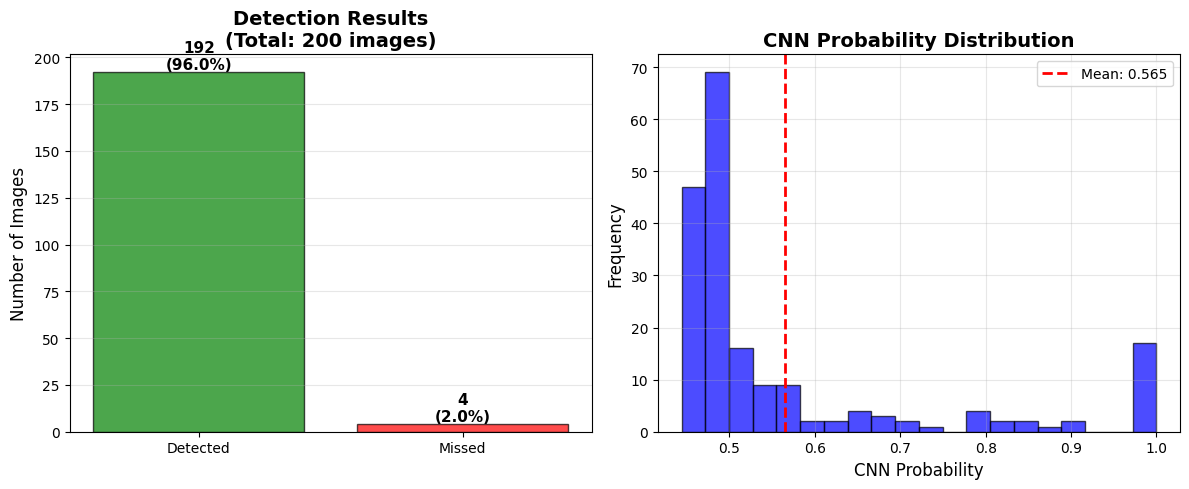


=== Summary ===
Metric                    Value          
----------------------------------------
Total Images              200
Detected (TP+FP)          192
Missed (FN)               4
Recall (Detection Rate)   0.9600 (96.00%)
Precision                 0.5000 (50.00%)


In [ ]:
import matplotlib.pyplot as plt

try:
    if 'TP' in locals() and 'FP' in locals() and 'FN' in locals() and 'TN' in locals():
        total_images = TP + FP + FN + TN
        detected = TP + FP
        missed = FN

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        ax1 = axes[0]
        categories = ['Detected', 'Missed']
        counts = [detected, missed]
        colors = ['green', 'red']
        bars = ax1.bar(categories, counts, color=colors, alpha=0.7, edgecolor='black')
        ax1.set_ylabel('Number of Images', fontsize=12)
        ax1.set_title(f'Detection Results\n(Total: {total_images:,} images)', fontsize=14, fontweight='bold')
        ax1.grid(axis='y', alpha=0.3)

        for bar, count in zip(bars, counts):
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                     f'{count:,}\n({count/total_images*100:.1f}%)',
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

        ax2 = axes[1]
        if detector.cnn is not None and 'all_detections' in locals():
            cnn_probs = [d['cnn_prob'] for d in all_detections if d['cnn_prob'] is not None]
            if len(cnn_probs) > 0:
                ax2.hist(cnn_probs, bins=20, color='blue', alpha=0.7, edgecolor='black')
                ax2.axvline(np.mean(cnn_probs), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(cnn_probs):.3f}')
                ax2.set_xlabel('CNN Probability', fontsize=12)
                ax2.set_ylabel('Frequency', fontsize=12)
                ax2.set_title('CNN Probability Distribution', fontsize=14, fontweight='bold')
                ax2.legend()
                ax2.grid(alpha=0.3)
            else:
                ax2.text(0.5, 0.5, 'No CNN probabilities\navailable',
                         ha='center', va='center', fontsize=12, transform=ax2.transAxes)
                ax2.set_title('CNN Probability Distribution', fontsize=14, fontweight='bold')
        else:
            ax2.text(0.5, 0.5, 'CNN not used\nor no detections',
                     ha='center', va='center', fontsize=12, transform=ax2.transAxes)
            ax2.set_title('CNN Probability Distribution', fontsize=14, fontweight='bold')

        plt.tight_layout()
        plt.show()

        print("\n=== Summary ===")
        print(f"{'Metric':<25} {'Value':<15}")
        print("-" * 40)
        print(f"{'Total Images':<25} {total_images:,}")
        print(f"{'Detected (TP+FP)':<25} {detected:,}")
        print(f"{'Missed (FN)':<25} {missed:,}")
        if 'recall' in locals():
            print(f"{'Recall (Detection Rate)':<25} {recall:.4f} ({recall*100:.2f}%)")
        if 'precision' in locals():
            print(f"{'Precision':<25} {precision:.4f} ({precision*100:.2f}%)")
    else:
        print("Evaluation metrics not found. Please run the evaluation cell first.")
except Exception as e:
    print(f"Error in visualization: {e}")
    print("Please run the evaluation cell first.")



Processing: broken-car-vehicle-vintage.jpg


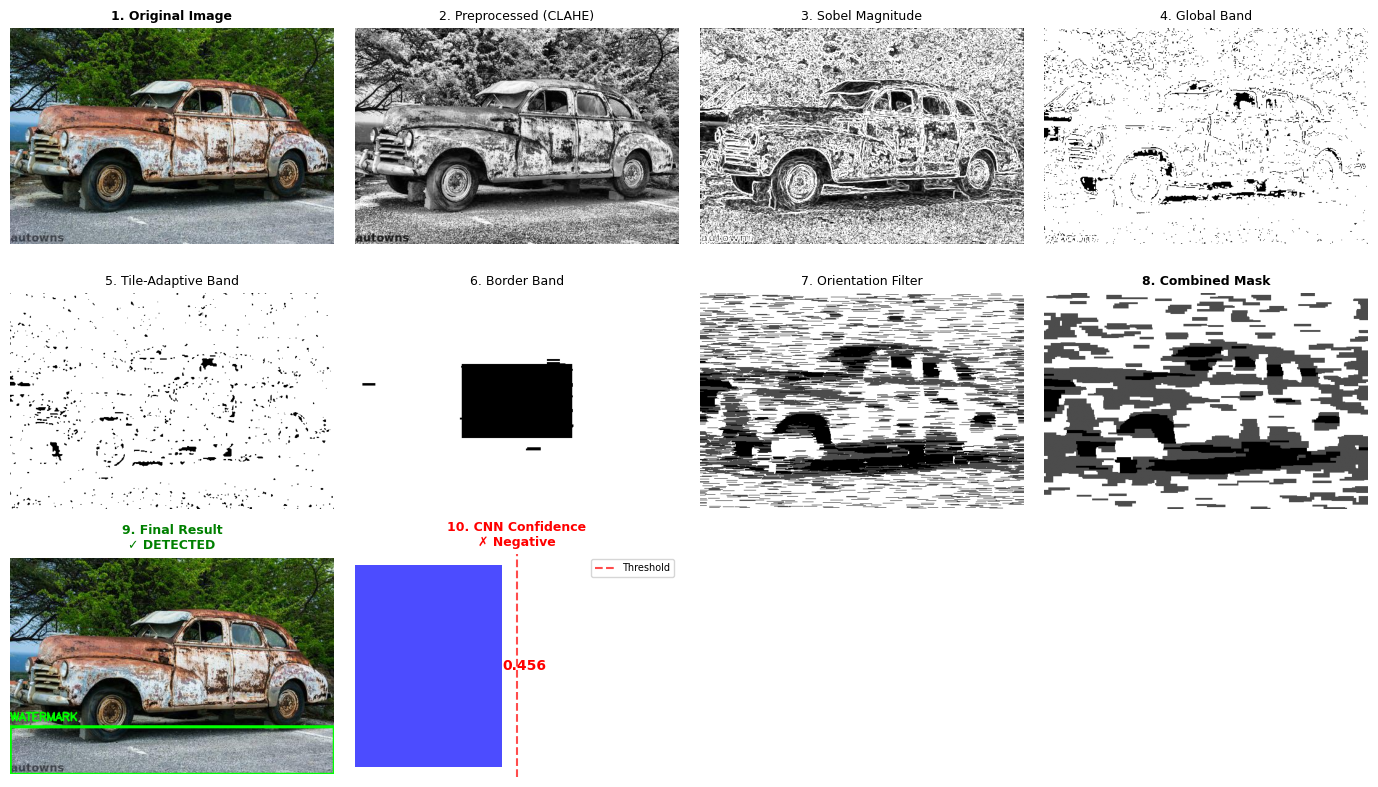

CNN probability: 0.456
Detected boxes: 1

Processing: bald-eagle-adler-bird-of-prey-raptor.jpg


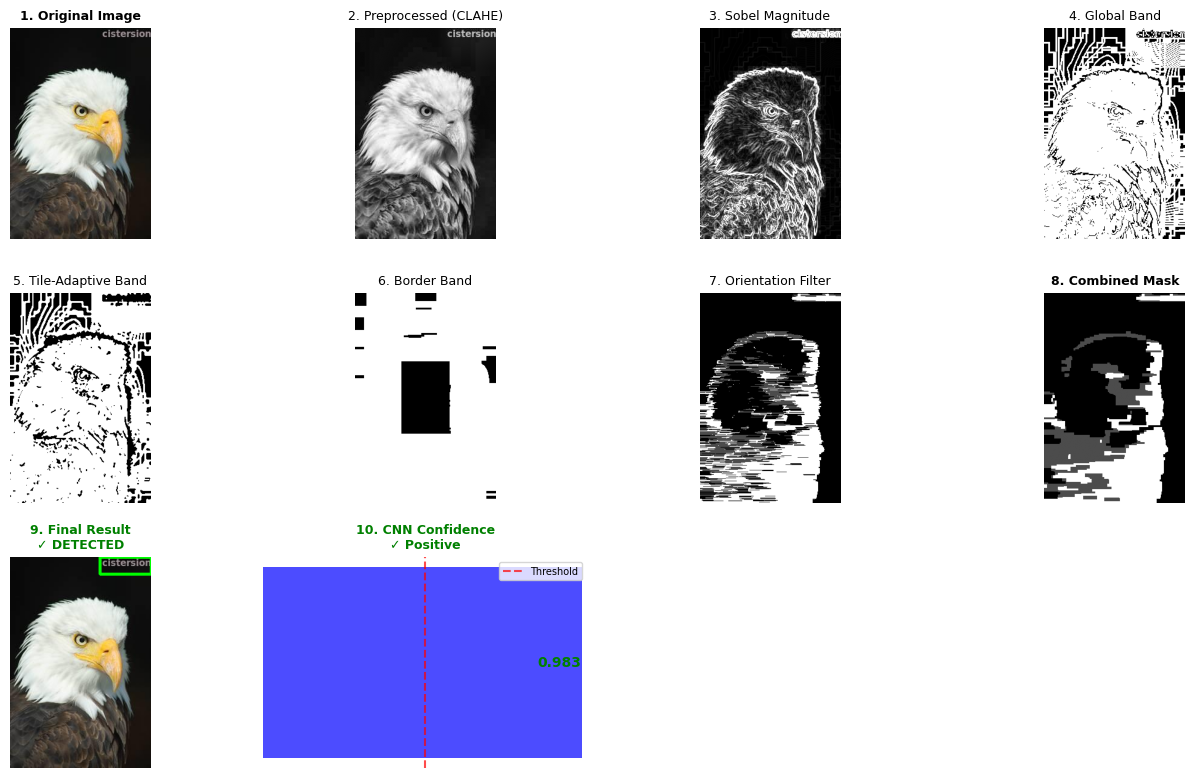

CNN probability: 0.983
Detected boxes: 1

Processing: lawn-meadow-close-up-view-animals.jpg


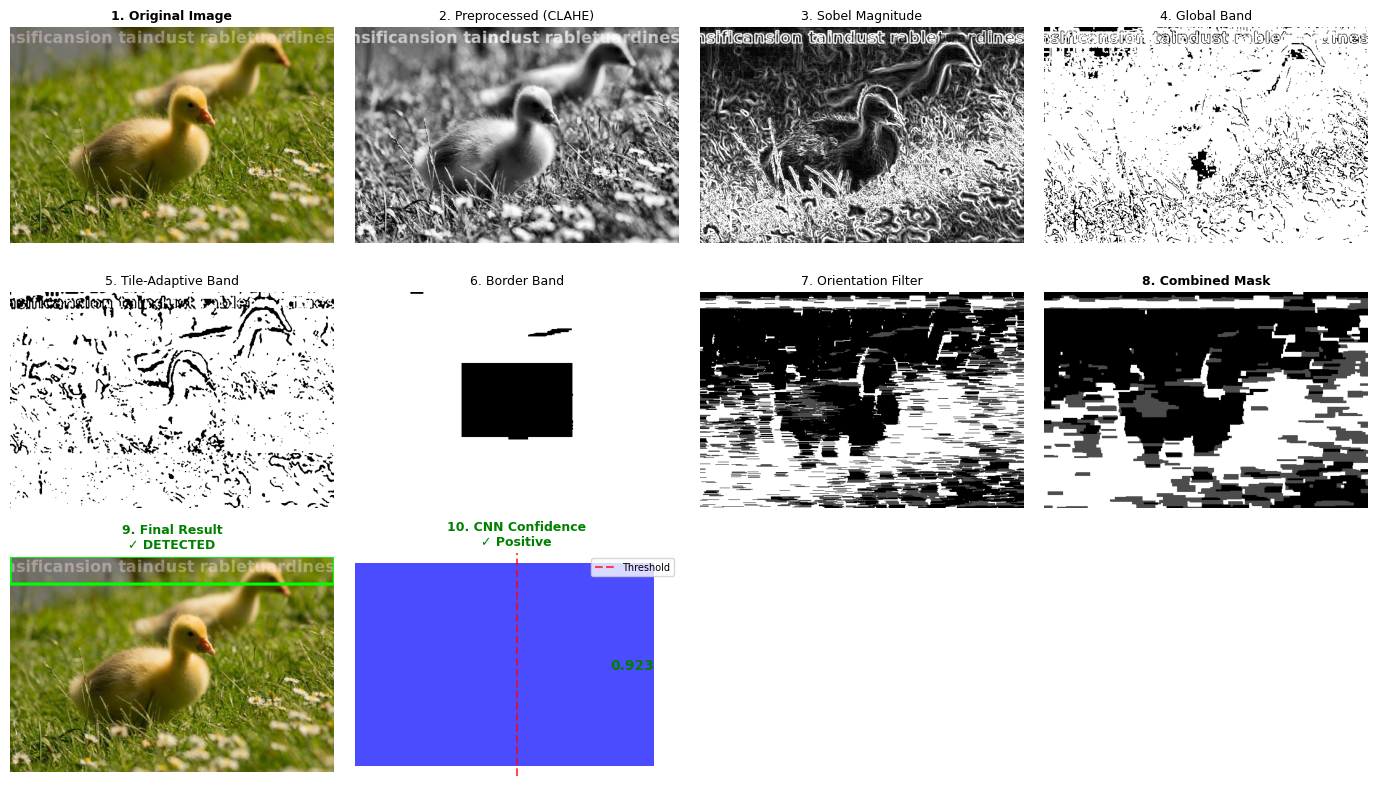

CNN probability: 0.923
Detected boxes: 1

Processing: lake-animals-dogs-pets.jpg


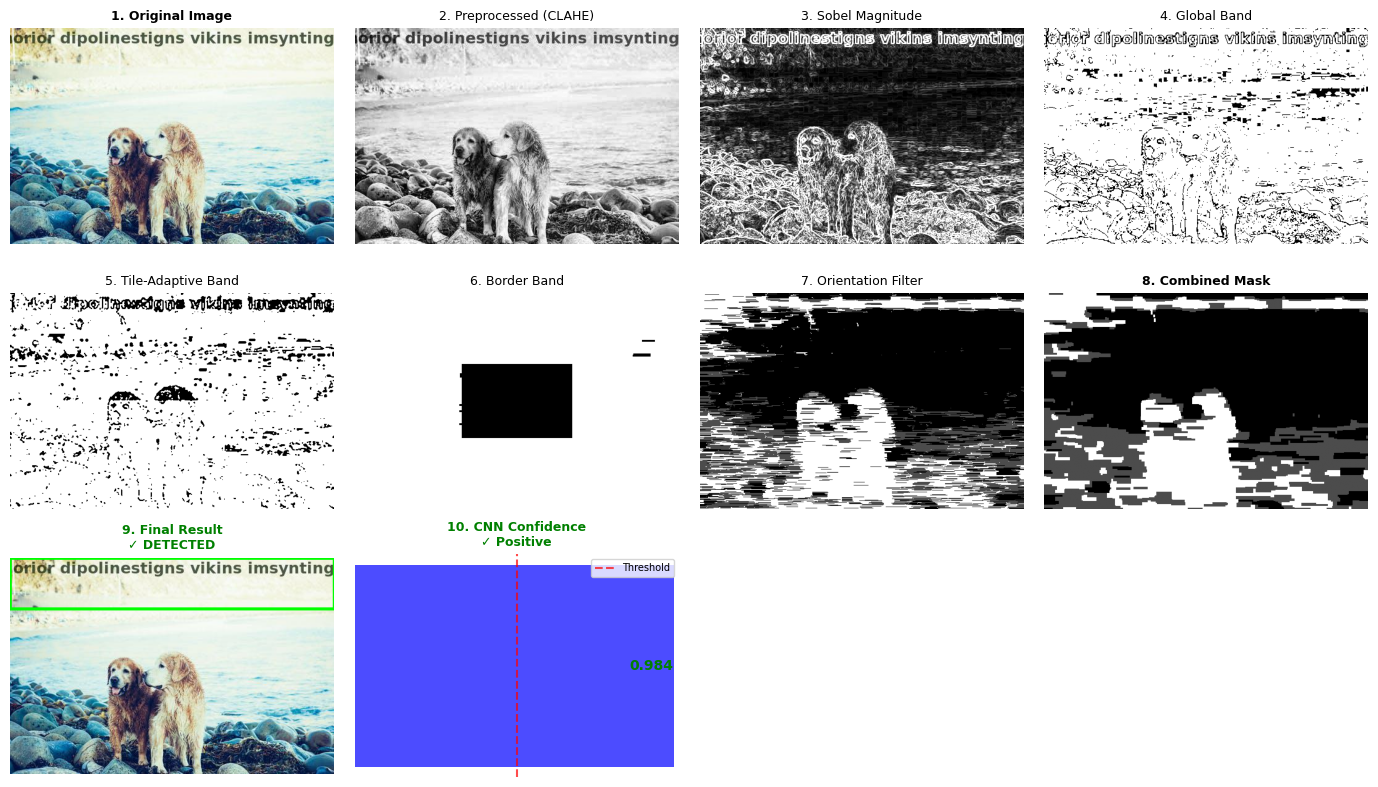

CNN probability: 0.984
Detected boxes: 1

Processing: light-road-nature-iphone.jpg


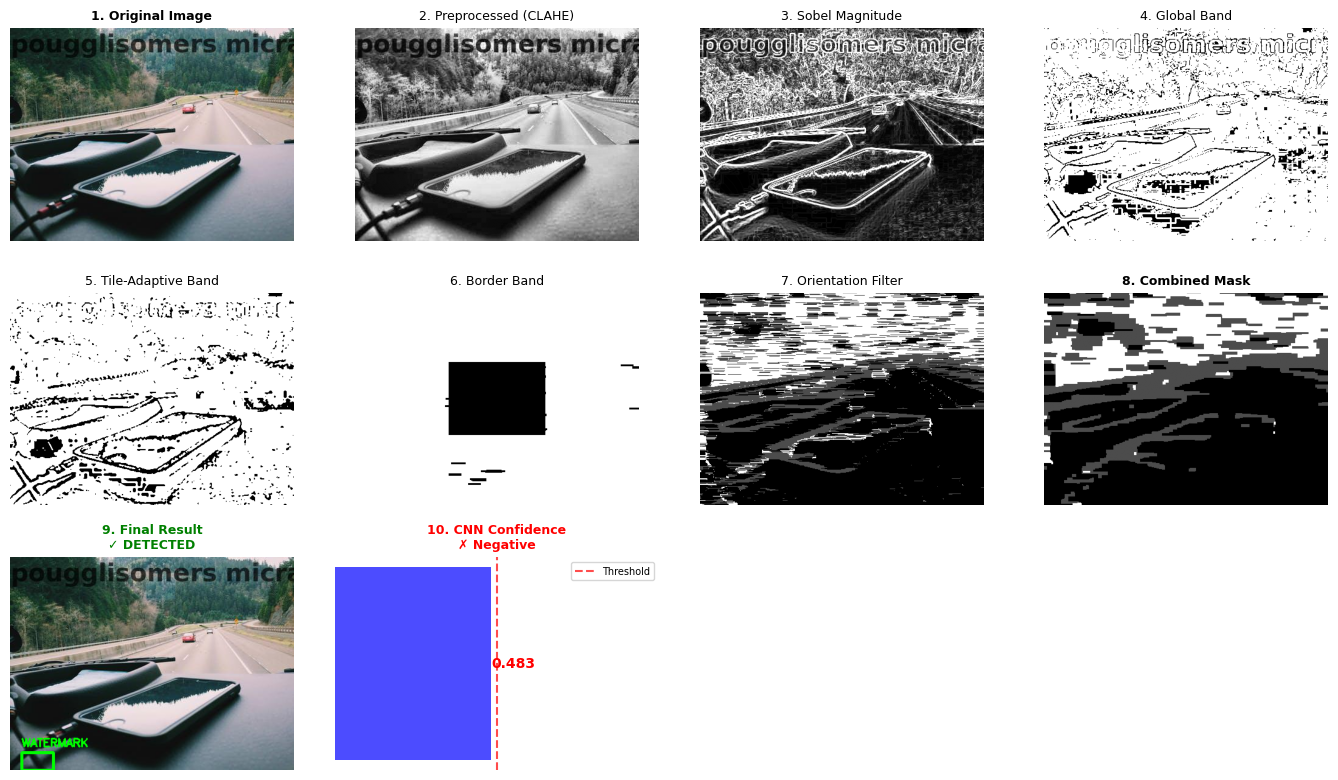

CNN probability: 0.483
Detected boxes: 1


In [ ]:
# 테스트 이미지 선택 및 감지 실행
test_images = list(watermarked_dir.glob("*.jpg"))[:5]  # 처음 5개 이미지 테스트

for img_path in test_images:
    print(f"\nProcessing: {img_path.name}")
    image = cv2.imread(str(img_path))
    if image is None:
        continue

    # 감지 실행
    d = detector.detect_watermark_with_sobel(image)
    results = {
        'original': image,
        'gray': d['gray'],
        'sobel_x': d['sobel_x'],
        'sobel_y': d['sobel_y'],
        'sobel_magnitude': d['magnitude'],
        'preprocessed': d['gray'],
        'global_band': d['global_band'],
        'tile_adaptive': d['tile_adaptive_mask'],
        'border_band': d['border_band'],
        'orientation_filter': d['orientation_filter'],
        'combined_mask': d['combined_mask'],
        'bounding_boxes': d['boxes'],
    }

    # 결과 시각화
    visualize_results(results)

    # CNN 확률 출력 (있는 경우)
    if detector.last_max_prob is not None:
        print(f"CNN probability: {detector.last_max_prob:.3f}")
    print(f"Detected boxes: {len(results['bounding_boxes'])}")


In [ ]:
print("=== Sobel + CNN Classification Metrics ===")
print("Evaluating detector with CNN scoring: watermark vs no-watermark\n")

if detector.cnn is None:
    print("CNN model is not loaded. Please train or load a CNN model first.")
    print("Skipping CNN evaluation.")
else:
    MAX_EVAL_IMAGES = 100

    watermarked_images = list(watermarked_dir.glob("*.*"))[:MAX_EVAL_IMAGES] if MAX_EVAL_IMAGES else list(watermarked_dir.glob("*.*"))
    no_watermark_images = list(clean_dir.glob("*.*"))[:MAX_EVAL_IMAGES] if MAX_EVAL_IMAGES else list(clean_dir.glob("*.*"))

    all_images = []
    for img_path in watermarked_images:
        all_images.append((img_path, 1))
    for img_path in no_watermark_images:
        all_images.append((img_path, 0))

    print(f"Total images to evaluate: {len(all_images):,}")
    print(f"  - Watermarked images: {len(watermarked_images):,}")
    print(f"  - No-watermark images: {len(no_watermark_images):,}\n")

    TP_cnn = 0
    FP_cnn = 0
    FN_cnn = 0
    TN_cnn = 0

    CNN_THRESHOLD = 0.5

    all_detections_cnn = []
    all_boxes_info_cnn = []

    for img_path, true_label in tqdm(all_images, desc="Evaluating with CNN"):
        try:
            image = cv2.imread(str(img_path))
            if image is None:
                continue

            results = detector.detect_watermark_with_sobel(image)
            boxes = results['boxes']
            cnn_prob = detector.last_max_prob if detector.last_max_prob is not None else 0.0

            pred_label = 1 if (len(boxes) > 0 and cnn_prob >= CNN_THRESHOLD) else 0

            if true_label == 1 and pred_label == 1:
                TP_cnn += 1
            elif true_label == 0 and pred_label == 1:
                FP_cnn += 1
            elif true_label == 1 and pred_label == 0:
                FN_cnn += 1
            elif true_label == 0 and pred_label == 0:
                TN_cnn += 1

            H, W = image.shape[:2]
            for box in boxes:
                x, y, w, h = box
                box_area = w * h
                box_ratio = w / h if h > 0 else 0
                center_x, center_y = x + w/2, y + h/2
                img_center_x, img_center_y = W/2, H/2
                distance_from_center = np.sqrt((center_x - img_center_x)**2 + (center_y - img_center_y)**2)
                normalized_distance = distance_from_center / np.sqrt(W**2 + H**2)

                all_boxes_info_cnn.append({
                    'area': box_area,
                    'width': w,
                    'height': h,
                    'aspect_ratio': box_ratio,
                    'area_ratio': box_area / (H * W),
                    'distance_from_center': normalized_distance,
                    'x': x,
                    'y': y
                })

            all_detections_cnn.append({
                'image': img_path.name,
                'true_label': true_label,
                'pred_label': pred_label,
                'num_boxes': len(boxes),
                'cnn_prob': cnn_prob,
                'boxes': boxes
            })
        except Exception as e:
            print(f"Error processing {img_path.name}: {e}")
            continue

    total_cnn = TP_cnn + FP_cnn + FN_cnn + TN_cnn
    accuracy_cnn = (TP_cnn + TN_cnn) / (total_cnn + EPS)
    precision_cnn = TP_cnn / (TP_cnn + FP_cnn + EPS)
    recall_cnn = TP_cnn / (TP_cnn + FN_cnn + EPS)
    f1_cnn = 2 * (precision_cnn * recall_cnn) / (precision_cnn + recall_cnn + EPS)
    specificity_cnn = TN_cnn / (TN_cnn + FP_cnn + EPS)

    print(f"\n=== Confusion Matrix (Sobel + CNN) ===")
    print(f"                Predicted")
    print(f"              Positive  Negative")
    print(f"Actual Positive  {TP_cnn:4d}     {FN_cnn:4d}")
    print(f"       Negative  {FP_cnn:4d}     {TN_cnn:4d}")

    print(f"\n=== Sobel + CNN Classification Metrics ===")
    print(f"CNN Threshold: {CNN_THRESHOLD}")
    print(f"{'Metric':<30} {'Value':<15} {'Description'}")
    print("-" * 70)
    print(f"{'Accuracy':<30} {accuracy_cnn:.4f} ({accuracy_cnn*100:.2f}%)  {'(TP + TN) / Total'}")
    print(f"{'Precision':<30} {precision_cnn:.4f} ({precision_cnn*100:.2f}%)  {'When I say watermark, how often am I right?'}")
    print(f"{'Recall (Sensitivity)':<30} {recall_cnn:.4f} ({recall_cnn*100:.2f}%)  {'How many real watermarks do I catch?'}")
    print(f"{'F1-Score':<30} {f1_cnn:.4f} ({f1_cnn*100:.2f}%)  {'Harmonic mean of precision & recall'}")
    print(f"{'Specificity':<30} {specificity_cnn:.4f} ({specificity_cnn*100:.2f}%)  {'True Negative Rate'}")
    print(f"\n=== Additional Metrics ===")
    print(f"{'False Positive Rate':<30} {FP_cnn/(FP_cnn+TN_cnn+EPS):.4f} ({FP_cnn/(FP_cnn+TN_cnn+EPS)*100:.2f}%)  {'FP / (FP + TN)'}")
    print(f"{'False Negative Rate':<30} {FN_cnn/(TP_cnn+FN_cnn+EPS):.4f} ({FN_cnn/(TP_cnn+FN_cnn+EPS)*100:.2f}%)  {'FN / (TP + FN)'}")
    print(f"\n=== IoU (Intersection over Union) ===")
    print(f"{'Note':<30} {'N/A (Ground Truth required)'}  {'IoU requires GT masks to calculate localization accuracy'}")

    cnn_probs_cnn = [d['cnn_prob'] for d in all_detections_cnn if d['cnn_prob'] is not None and d['cnn_prob'] > 0]
    if len(cnn_probs_cnn) > 0:
        print(f"\n=== CNN Confidence Metrics ===")
        print(f"{'Metric':<30} {'Value':<15}")
        print("-" * 45)
        print(f"{'Mean Confidence':<30} {np.mean(cnn_probs_cnn):.4f}")
        print(f"{'Std Confidence':<30} {np.std(cnn_probs_cnn):.4f}")
        print(f"{'Min Confidence':<30} {np.min(cnn_probs_cnn):.4f}")
        print(f"{'Max Confidence':<30} {np.max(cnn_probs_cnn):.4f}")
        print(f"{'Confidence > 0.5':<30} {sum(1 for p in cnn_probs_cnn if p > 0.5):,} ({sum(1 for p in cnn_probs_cnn if p > 0.5)/len(cnn_probs_cnn)*100:.2f}%)")
        print(f"{'Confidence > 0.7':<30} {sum(1 for p in cnn_probs_cnn if p > 0.7):,} ({sum(1 for p in cnn_probs_cnn if p > 0.7)/len(cnn_probs_cnn)*100:.2f}%)")

    box_counts_cnn = [d['num_boxes'] for d in all_detections_cnn]
    print(f"\n=== Detection Statistics ===")
    print(f"{'Metric':<30} {'Value':<15}")
    print("-" * 45)
    print(f"{'Mean boxes per image':<30} {np.mean(box_counts_cnn):.4f}")
    print(f"{'Max boxes per image':<30} {np.max(box_counts_cnn)}")
    print(f"{'Images with boxes':<30} {sum(1 for c in box_counts_cnn if c > 0):,} ({sum(1 for c in box_counts_cnn if c > 0)/len(all_detections_cnn)*100:.2f}%)")

    if len(all_boxes_info_cnn) > 0:
        print(f"\n=== Localization Quality (Predicted Box Characteristics) ===")
        print(f"{'Metric':<30} {'Mean':<15} {'Std':<15}")
        print("-" * 60)

        areas = [b['area'] for b in all_boxes_info_cnn]
        area_ratios = [b['area_ratio'] for b in all_boxes_info_cnn]
        aspect_ratios = [b['aspect_ratio'] for b in all_boxes_info_cnn]
        distances = [b['distance_from_center'] for b in all_boxes_info_cnn]

        print(f"{'Box Area (pixels)':<30} {np.mean(areas):<15.2f} {np.std(areas):<15.2f}")
        print(f"{'Box Area Ratio':<30} {np.mean(area_ratios):<15.4f} {np.std(area_ratios):<15.4f}")
        print(f"{'Aspect Ratio (W/H)':<30} {np.mean(aspect_ratios):<15.4f} {np.std(aspect_ratios):<15.4f}")
        print(f"{'Distance from Center':<30} {np.mean(distances):<15.4f} {np.std(distances):<15.4f}")

        border_threshold = 0.1
        border_boxes = sum(1 for b in all_boxes_info_cnn if b['distance_from_center'] > (1 - border_threshold))
        print(f"{'Boxes near border (>90%)':<30} {border_boxes:,} ({border_boxes/len(all_boxes_info_cnn)*100:.2f}%)")


=== Sobel + CNN Classification Metrics ===
Evaluating detector with CNN scoring: watermark vs no-watermark

Total images to evaluate: 200
  - Watermarked images: 100
  - No-watermark images: 100



Evaluating with CNN: 100%|██████████| 200/200 [00:09<00:00, 20.84it/s]


=== Confusion Matrix (Sobel + CNN) ===
                Predicted
              Positive  Negative
Actual Positive    45       55
       Negative    30       70

=== Sobel + CNN Classification Metrics ===
CNN Threshold: 0.5
Metric                         Value           Description
----------------------------------------------------------------------
Accuracy                       0.5750 (57.50%)  (TP + TN) / Total
Precision                      0.6000 (60.00%)  When I say watermark, how often am I right?
Recall (Sensitivity)           0.4500 (45.00%)  How many real watermarks do I catch?
F1-Score                       0.5143 (51.43%)  Harmonic mean of precision & recall
Specificity                    0.7000 (70.00%)  True Negative Rate

=== Additional Metrics ===
False Positive Rate            0.3000 (30.00%)  FP / (FP + TN)
False Negative Rate            0.5500 (55.00%)  FN / (TP + FN)

=== IoU (Intersection over Union) ===
Note                           N/A (Ground Truth required) 